# Rasterize ↔ vectorize

Cross the raster/vector divide both ways:

- **Vectorize** a raster: `to_feature_collection()` (polygonize equal-valued regions) and
  `contour(interval=...)` (iso-value lines).
- **Rasterize** a vector: `Dataset.from_features(fc, ...)` burns an attribute column into a
  new raster grid.

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import numpy as np

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-ops-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

ds = Dataset.read_file(DATA / 'acc4000.tif')
ds.shape, ds.epsg

((1, 13, 14), 32618)

## Vectorize — polygonize

`to_feature_collection(add_geometry='Polygon')` merges equal-valued cells into polygons.

In [3]:
polys = ds.to_feature_collection(add_geometry='Polygon')
type(polys).__name__, len(polys), list(polys.columns)

('GeoDataFrame', 89, ['Band_1', 'geometry'])

Plot the polygons produced by polygonizing the raster — each equal-valued region becomes a polygon.

<Axes: >

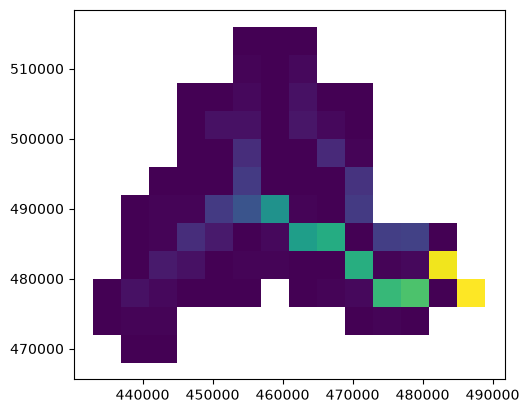

In [4]:
polys.plot(column='Band_1')

## Vectorize — contour lines

`contour(interval=...)` traces iso-value lines into a `FeatureCollection`.

In [5]:
lines = ds.contour(interval=10.0)
type(lines).__name__, len(lines)

('FeatureCollection', 19)

## Rasterize — burn a vector into a raster

`Dataset.from_features` rasterises an attribute column onto a new grid. Give it a numeric
column to burn and a `cell_size` (or a `template` raster to inherit the grid).

In [6]:
zones = FeatureCollection.read_file(DATA / 'coello_polygons.geojson')
zones['value'] = np.arange(1, len(zones) + 1, dtype='int32')  # numeric column to burn
burned = Dataset.from_features(zones, cell_size=ds.cell_size, column_name='value')
burned.shape, burned.epsg

((1, 13, 13), 32618)

The round-trip, visualized: the source vector zones (coloured by the `value` column) and the raster they
were burned into.

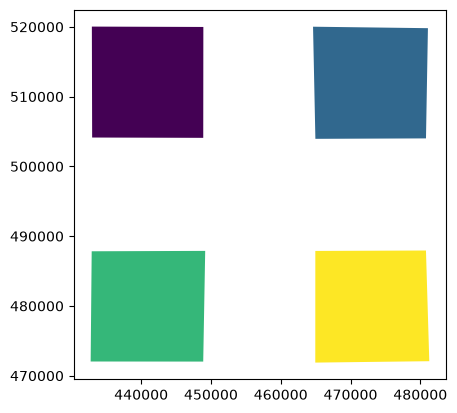

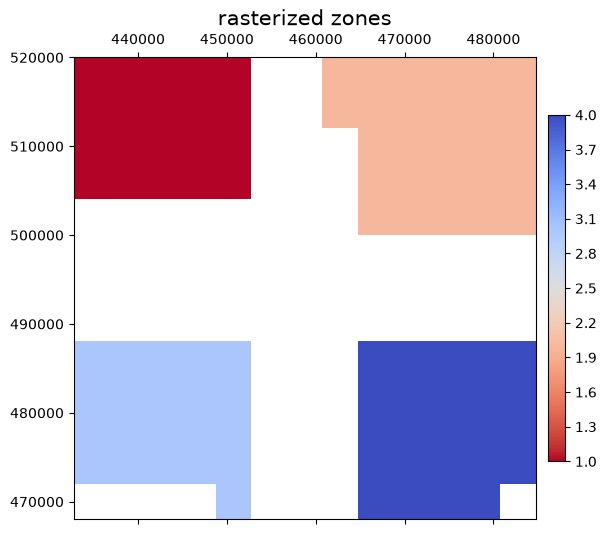

In [7]:
zones.plot(column='value')
burned.plot(band=0, title='rasterized zones')

## Notes

- `to_feature_collection()` without `add_geometry` returns a plain table of cell values;
  pass `add_geometry='Polygon'` (or `'Point'`) to attach geometry.
- `from_features(..., template=ds)` inherits an existing raster's grid instead of `cell_size`.
- `sieve()` removes speckle (small regions) before vectorizing — useful on classified rasters.
- See also: [Zonal statistics](zonal-statistics.ipynb), [Crop & mask](crop-mask.ipynb).